# model 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
API_key = os.getenv("GOOGLE_API_KEY")
llm_model = "gemini-2.5-flash"

In [3]:
os.environ["LANGCHAIN_PROJECT"] = "Time Travel"

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
model = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    timeout=None,
                    max_retries=2)

# Goals 

- LangGraph supports time travel through checkpoints:
    - Replay: Retry from a prior checkpoint.
    - Fork: Branch from a prior checkpoint with modified state to explore an alternative path.

# Build Graph 

In [6]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [7]:
tools = [add, multiply, divide]
llm_with_tools = model.bind_tools(tools)

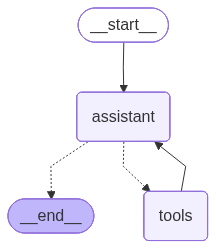

In [8]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (90cd7d8d-d6fc-4f26-9e01-148764ec8909)
 Call ID: 90cd7d8d-d6fc-4f26-9e01-148764ec8909
  Args:
    b: 3
    a: 2
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is 6.


# Browsing History
- We can use get_state to look at the current state of our graph, given the thread_id!

In [12]:
graph.get_state({'configurable': {'thread_id': '1'}}) 

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6fa69e5d-7458-4da8-829c-001f51a73c58'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 3, "a": 2}'}, '__gemini_function_call_thought_signatures__': {'90cd7d8d-d6fc-4f26-9e01-148764ec8909': 'CvwBAb4+9vso+yxfRxmOYHbjvgz/E3GVAbCOQotYw39Ius/ldSQVKSPpjTpk5CSO4Ng9l88EDSkexdh9kGf7+a9VvSBssyiVLFq5XajhiL6dBY9yMrWNvL6OKfVb/Dj/2GL3vJfnXr7L8tULnE5P4cubru+uomXqOd+qDo5b0vNcLlvKWf+tfxGqRN+/m966s96G7yDqlKKQBFZ8JFYAABJltB3av7xYGkZxA7rvM1a9EzikZT9bb5fwBJ+blkh+vMpAVy+I5hsH8AWIA6/RDIrgzj+x4FnR8wg73iUWFCx6jEUnB+UAFbx9SSdMDAYnloKJIxibzYCNSz+bOL2S'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d4263-ad6d-72c1-bced-9426b11cdbb0-0', tool_calls=[{'name': 'multiply', 'args': {'b': 3, 'a': 2}, 'id': '90cd7d8d-d6fc-4f26-9e01-148764ec890

- get_state_history lets us get the state at all prior steps.

In [13]:
all_states = [s for s in graph.get_state_history(thread)]

In [14]:
len(all_states)

5

In [19]:
all_states[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6fa69e5d-7458-4da8-829c-001f51a73c58')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc36-9278-6151-8000-4fdc80611bb1'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-31T05:35:21.963747+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc36-9273-6e9c-bfff-77df4489d75b'}}, tasks=(PregelTask(id='f0b5756b-2bbf-8ecb-9934-3a2aaa02e32d', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"b": 3, "a": 2}'}, '__gemini_function_call_thought_signatures__': {'90cd7d8d-d6fc-4f26-9e01-148764ec8909': 'CvwBAb4+9vso+yxfRxmOYHbjvgz/E3GVAbCOQotYw39Ius/ldSQVKSPpjTpk5CSO4Ng9l88EDSkexdh9